# Pertemuan 13 - Pengantar Deep Learning & NLP Dasar

**Nama:** Moch Faris Oldie  
**NIM:** 250401020048  
**Kelas:** IF401

**Tujuan:** membangun neural network sederhana dengan Keras/TensorFlow untuk klasifikasi data non-linear, serta menerapkan TF-IDF untuk analisis sentimen teks.

## Bagian A: Neural Network untuk Klasifikasi Non-Linear

## 1. Generate & Eksplorasi Dataset

Gunakan `make_moons` (300 titik, dua kelas berbentuk bulan sabit) yang tidak dapat dipisahkan oleh satu garis lurus.

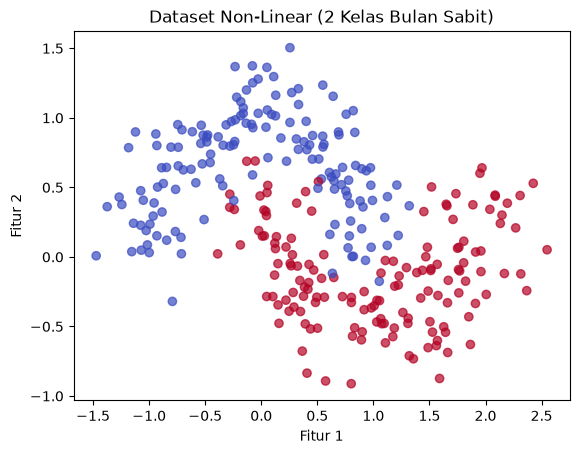

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.xlabel('Fitur 1'); plt.ylabel('Fitur 2')
plt.show()

Kedua kelas saling melengkung dan bertautan, sehingga tidak bisa dipisahkan dengan satu garis lurus — diperlukan activation function non-linear (ReLU) pada hidden layer.

## 2. Bangun & Latih Neural Network

Arsitektur: input 2 fitur → Dense(16, relu) → Dense(8, relu) → Dense(1, sigmoid). Loss binary_crossentropy, optimizer adam.

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)
print('Pelatihan selesai.')

Pelatihan selesai.


## 3. Evaluasi & Visualisasi Kurva Belajar

Akurasi pada data uji: 0.917

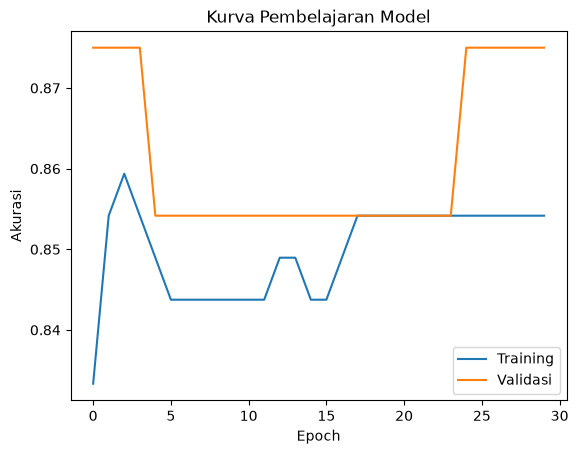

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch'); plt.ylabel('Akurasi')
plt.legend(); plt.title('Kurva Pembelajaran Model')
plt.show()

Kurva akurasi training dan validasi saling mendekat seiring bertambahnya epoch, menandakan model belajar dengan baik dan tidak menunjukkan overfitting yang parah.

## Bagian B: Analisis Sentimen dengan TF-IDF

## 4. Siapkan Dataset Ulasan Produk

40 ulasan produk sintetis berbahasa Indonesia berlabel sentimen (1 = positif, 0 = negatif).

In [5]:
ulasan = [
    'Barangnya bagus banget', 'Barangnya rusak saat sampai',
    'Kualitasnya terbaik', 'Kualitasnya jelek sekali',
    'Sangat puas dengan produk', 'Sangat kecewa dengan produk',
    'Pengiriman cepat sekali', 'Pengirimannya sangat lambat',
    'Harga sesuai dengan kualitasnya', 'Tidak sesuai dengan deskripsi',
    'Pelayanannya ramah dan sopan', 'Barangnya cacat produksi',
    'Sesuai dengan gambar dan deskripsi', 'Menyesal sudah membeli',
    'Sangat recommended untuk dibeli', 'Kualitasnya buruk dan tidak layak',
    'Produknya mantap dan awet', 'Mengecewakan sekali, tidak sesuai iklan',
    'Tahan lama dan worth it', 'Barang datang dalam kondisi rusak',
    'Sangat memuaskan, terima kasih', 'Menghabiskan uang untuk barang buruk',
    'Kualitas premium, harga terjangkau', 'Tidak akan beli lagi, jelek',
    'Packing rapi dan aman', 'Rusak parah dan tidak berfungsi',
    'Bintang lima untuk produk ini', 'Kualitas tidak sesuai dengan harganya',
    'Produk original dan berkualitas', 'Sangat mengecewakan, tidak layak pakai',
    'Cocok banget untuk kebutuhan saya', 'Pengalaman belanja yang buruk',
    'Kualitasnya bagus untuk harga segini', 'Kecewa berat dengan kualitasnya',
    'Pengalaman belanja yang menyenangkan', 'Barang jelek dan cepat rusak',
    'Sangat membantu, puas sekali', 'Tidak puas, barang tidak sesuai',
    'Produknya luar biasa, terbaik', 'Sayang sekali, kualitasnya menurun',
]

label = [1, 0] * (len(ulasan) // 2)  # 1 = positif, 0 = negatif

print('Jumlah ulasan:', len(ulasan))
print('Contoh:', ulasan[0], '->', label[0])

Jumlah ulasan: 40
Contoh: Barangnya bagus banget -> 1


## 5. Ubah Teks Menjadi TF-IDF

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('10 kata pertama  :', tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 88
10 kata pertama  : ['akan' 'aman' 'awet' 'bagus' 'banget' 'barang' 'barangnya' 'belanja'
 'beli' 'berat']


In [7]:
kata_penting = np.array(tfidf.get_feature_names_out())[X_text.sum(axis=0).argsort()[::-1]][:10]
print('Kata dengan skor TF-IDF tertinggi:', kata_penting)

Kata dengan skor TF-IDF tertinggi: [['it' 'lama' 'worth' 'tahan' 'kebutuhan' 'saya' 'cocok' 'dalam' 'datang'
  'kondisi' 'lima' 'bintang' 'ini' 'akan' 'beli' 'lagi' 'uang'
  'menghabiskan' 'biasa' 'luar' 'premium' 'terjangkau' 'segini' 'pakai'
  'memuaskan' 'terima' 'kasih' 'menyenangkan' 'ramah' 'pelayanannya'
  'aman' 'packing' 'rapi' 'sopan' 'parah' 'berfungsi' 'saat' 'sampai'
  'iklan' 'mantap' 'awet' 'harganya' 'gambar' 'sudah' 'menyesal'
  'membeli' 'dibeli' 'menurun' 'sayang' 'recommended' 'berkualitas'
  'original' 'produksi' 'cacat' 'berat' 'membantu' 'pengirimannya'
  'lambat' 'pengiriman' 'produknya' 'mengecewakan' 'kualitas'
  'pengalaman' 'belanja' 'yang' 'banget' 'layak' 'bagus' 'cepat'
  'deskripsi' 'kecewa' 'terbaik' 'buruk' 'harga' 'barangnya' 'puas'
  'jelek' 'barang' 'rusak' 'produk' 'untuk' 'sekali' 'sesuai' 'sangat'
  'dengan' 'dan' 'kualitasnya' 'tidak']]


## 6. Latih Model Klasifikasi Sentimen & Evaluasi

Latih Logistic Regression pada vektor TF-IDF, lalu uji dengan kalimat baru.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression(max_iter=2000)
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

Akurasi model sentimen: 0.875


In [9]:
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah', 'Barangnya rusak dan mengecewakan']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

for k, p in zip(kalimat_baru, pred):
    print(f'[{k}] -> Sentimen: {"Positif" if p == 1 else "Negatif"}')

[Pelayanan sangat memuaskan dan ramah] -> Sentimen: Positif
[Barangnya rusak dan mengecewakan] -> Sentimen: Negatif


## Kesimpulan

Pada pertemuan ini saya mempelajari pengantar **Deep Learning** melalui Artificial Neural Network (neuron, weight, bias, activation function, forward pass dan backpropagation) dan menerapkannya dengan Keras/TensorFlow untuk kasus klasifikasi non-linear (make_moons), serta mempelajari **Natural Language Processing** dasar dengan mengubah teks menjadi vektor **TF-IDF** untuk analisis sentimen. Temuan utama: neural network dengan activation ReLU mampu memisahkan data bulan sabit yang tidak linear (akurasi tinggi di data uji), dan model TF-IDF + Logistic Regression mampu memprediksi sentimen ulasan dengan benar pada kalimat baru. Keterbatasan praktik ini adalah dataset ulasan sangat kecil (40 sampel) dan neural network hanya menggunakan satu lapisan sederhana; untuk teks yang lebih kompleks diperlukan data lebih besar dan model berbasis transformer seperti BERT atau LLM.